# Netflix Content EDA
 
## Problem Statement
Perform complete EDA on 8,807 Netflix titles to uncover
content trends, genre dominance, and platform growth.
 
## Dataset
Source : Kaggle Netflix Movies & TV Shows
Rows   : 8,807  |  Columns: 12  |  Period: 2008-2021
 
## Tools
Python | Pandas | Matplotlib | Seaborn | WordCloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install wordcloud
from wordcloud import WordCloud
 
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 130
print('Libraries imported')

Libraries imported


In [5]:
df = pd.read_csv('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Exploratory Data Analysis/Net_flix_EDA/data/raw/netflix_titles.csv')
print('Shape:', df.shape)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nContent Types:')
print(df['type'].value_counts())
df.head(3)

Shape: (8807, 12)

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Content Types:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [6]:
df['date_added']  = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
 
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
 
df.to_csv('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Exploratory Data Analysis/Net_flix_EDA/data/cleaned/netflix_cleaned.csv', index=False)
print('Cleaned dataset saved')
print('Date range:', int(df['year_added'].min()), 'to', int(df['year_added'].max()))
df.head(2)

C:\Users\BHANUPRAKASH\AppData\Local\Temp\ipykernel_16764\1317966870.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
C:\Users\BHANUPRAKASH\AppData\Local\Temp\ipykernel_16764\1317966870.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

Cleaned dataset saved
Date range: 2008 to 2021


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0


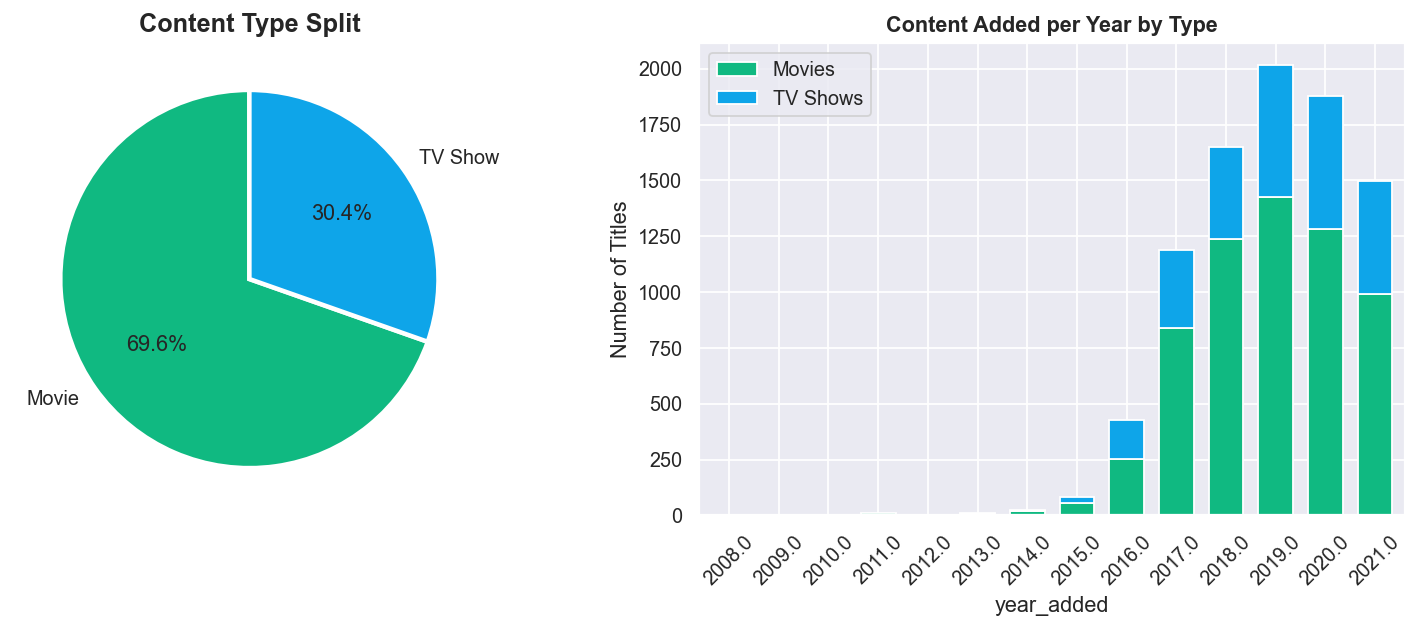

KEY FINDING: 69.6 % of Netflix content is Movies
KEY FINDING: 30.4 % is TV Shows


In [7]:
type_counts = df['type'].value_counts()
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].pie(type_counts,
            labels=type_counts.index,
            autopct='%1.1f%%',
            colors=['#10B981','#0EA5E9'],
            startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2.5})
axes[0].set_title('Content Type Split', fontsize=14, fontweight='bold')
 
yearly_type = df.groupby(['year_added','type']).size().unstack(fill_value=0)
yearly_type.plot(kind='bar', ax=axes[1],
                 color=['#10B981','#0EA5E9'],
                 stacked=True, rot=45, width=0.7)
axes[1].set_title('Content Added per Year by Type', fontweight='bold')
axes[1].set_ylabel('Number of Titles')
axes[1].legend(['Movies','TV Shows'])
 
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Exploratory Data Analysis/Net_flix_EDA/visuals/content_type_split.png', dpi=150, bbox_inches='tight')
plt.show()
 
movie_pct = type_counts['Movie'] / type_counts.sum() * 100
print('KEY FINDING:', round(movie_pct,1), '% of Netflix content is Movies')
print('KEY FINDING:', round(100-movie_pct,1), '% is TV Shows')

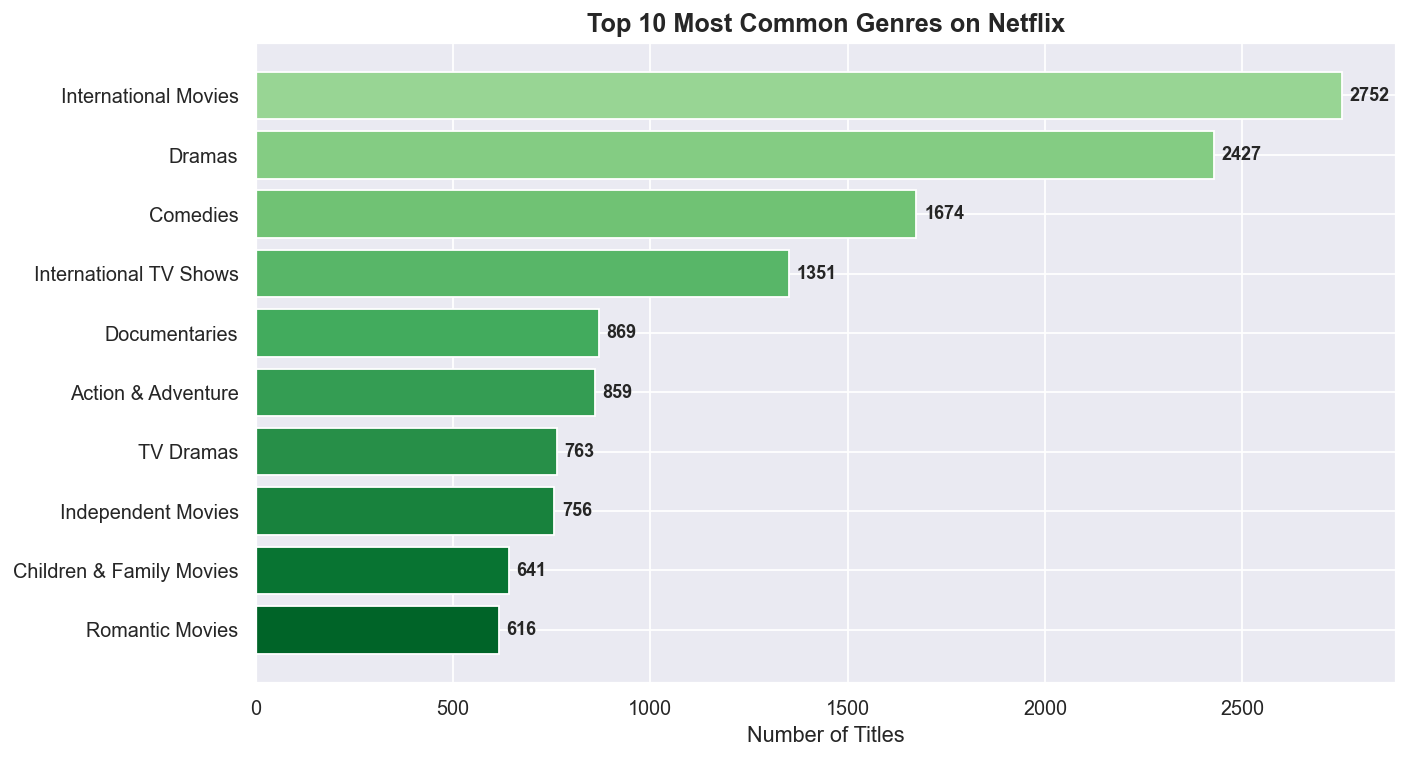

KEY FINDINGS - Top 5 Genres:
  International Movies : 2752 titles
  Dramas : 2427 titles
  Comedies : 1674 titles
  International TV Shows : 1351 titles
  Documentaries : 869 titles


In [8]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
 
fig, ax = plt.subplots(figsize=(11, 6))
colors_g = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_genres)))
bars = ax.barh(range(len(top_genres)), top_genres.values, color=colors_g)
ax.set_yticks(range(len(top_genres)))
ax.set_yticklabels(top_genres.index, fontsize=11)
ax.invert_yaxis()
for bar, val in zip(bars, top_genres.values):
    ax.text(bar.get_width()+20,
            bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')
ax.set_title('Top 10 Most Common Genres on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Exploratory Data Analysis/Net_flix_EDA/visuals/top10_genres.png', dpi=150, bbox_inches='tight')
plt.show()
 
print('KEY FINDINGS - Top 5 Genres:')
for genre, count in top_genres.head(5).items():
    print(' ', genre, ':', count, 'titles')

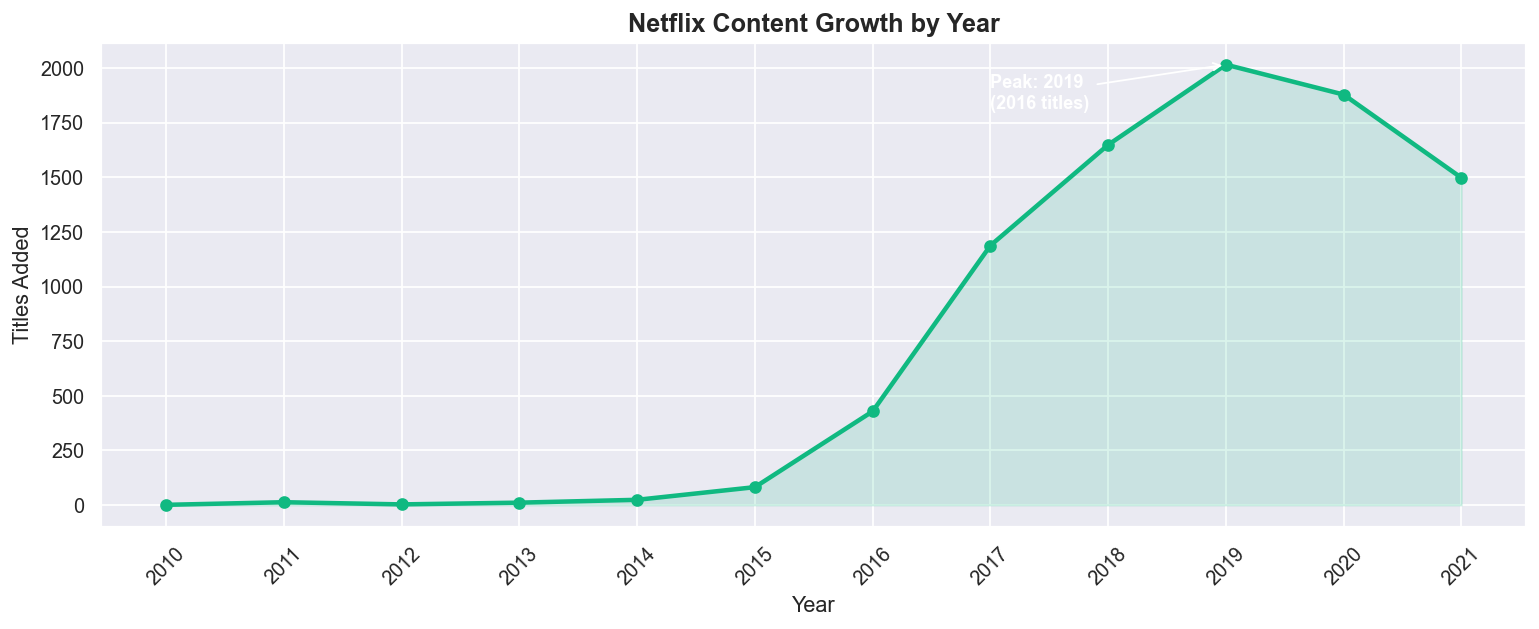

KEY FINDING: Content growth 2015 to 2019 = 2359.0 %
KEY FINDING: Peak year = 2019 ( 2016 titles)


In [9]:
yearly = df.groupby('year_added')['title'].count().dropna()
yearly = yearly[yearly.index >= 2010]
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly.index, yearly.values,
        color='#10B981', linewidth=2.5, marker='o', markersize=6)
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color='#10B981')
 
peak_yr  = int(yearly.idxmax())
peak_val = int(yearly.max())
ax.annotate('Peak: '+str(peak_yr)+'\n('+str(peak_val)+' titles)',
            xy=(peak_yr, peak_val),
            xytext=(peak_yr-2, peak_val-200),
            arrowprops=dict(arrowstyle='->', color='white'),
            color='white', fontsize=10, fontweight='bold')
 
ax.set_title('Netflix Content Growth by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')  ;  ax.set_ylabel('Titles Added')
ax.set_xticks(yearly.index)
ax.set_xticklabels([int(y) for y in yearly.index], rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Exploratory Data Analysis/Net_flix_EDA/visuals/content_growth_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
 
if 2015 in yearly.index and 2019 in yearly.index:
    growth = (yearly[2019] - yearly[2015]) / yearly[2015] * 100
    print('KEY FINDING: Content growth 2015 to 2019 =', round(growth,0), '%')
print('KEY FINDING: Peak year =', peak_yr, '(', peak_val, 'titles)')

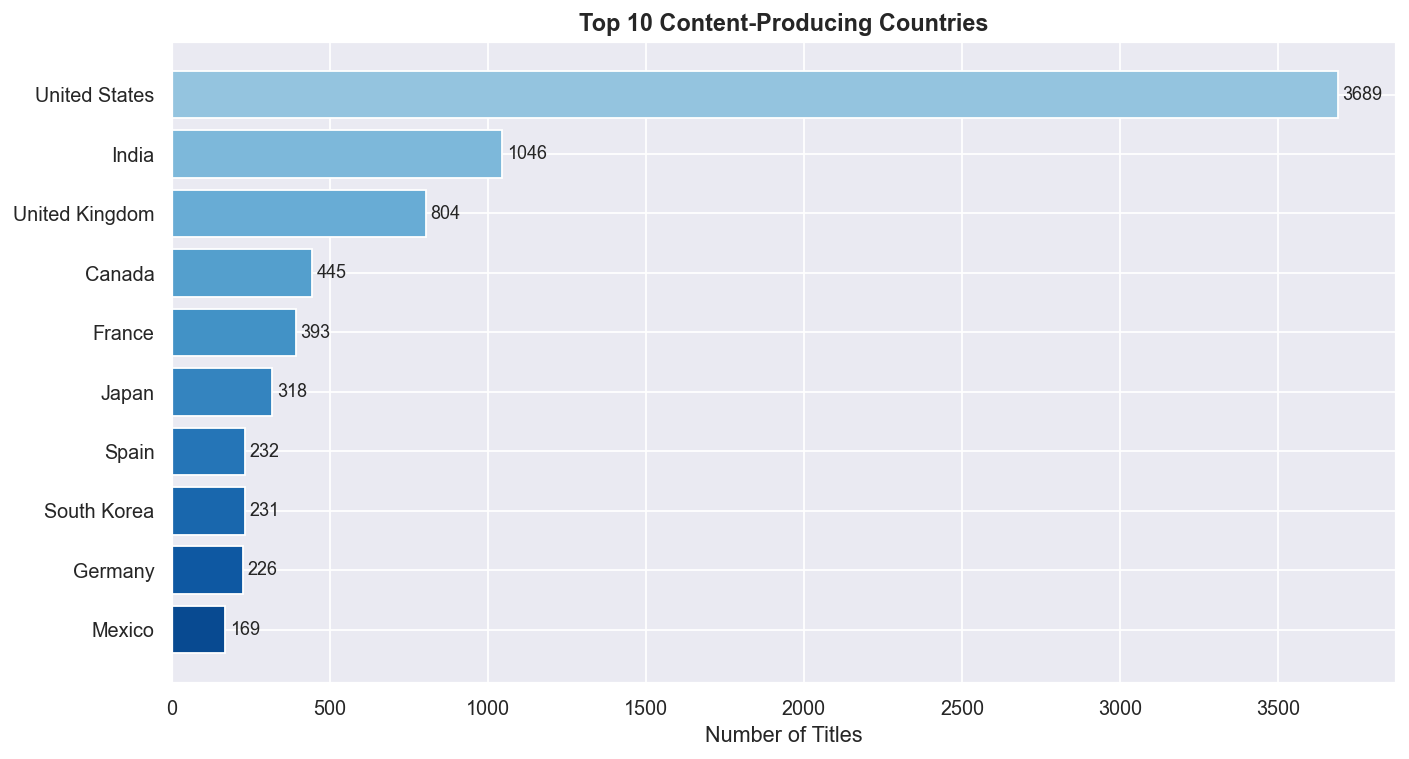

KEY FINDING: Top country = United States ( 3689 titles)


In [10]:
countries = df['country'].str.split(', ').explode()
countries = countries[countries != 'Unknown']
top_countries = countries.value_counts().head(10)
 
fig, ax = plt.subplots(figsize=(11, 6))
colors_c = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_countries)))
bars = ax.barh(range(len(top_countries)), top_countries.values, color=colors_c)
ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels(top_countries.index, fontsize=11)
ax.invert_yaxis()
for bar, val in zip(bars, top_countries.values):
    ax.text(bar.get_width()+15,
            bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=10)
ax.set_title('Top 10 Content-Producing Countries', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Exploratory Data Analysis/Net_flix_EDA/visuals/top10_countries.png', dpi=150, bbox_inches='tight')
plt.show()
 
top_country = top_countries.index[0]
top_count   = top_countries.iloc[0]
print('KEY FINDING: Top country =', top_country, '(', top_count, 'titles)')

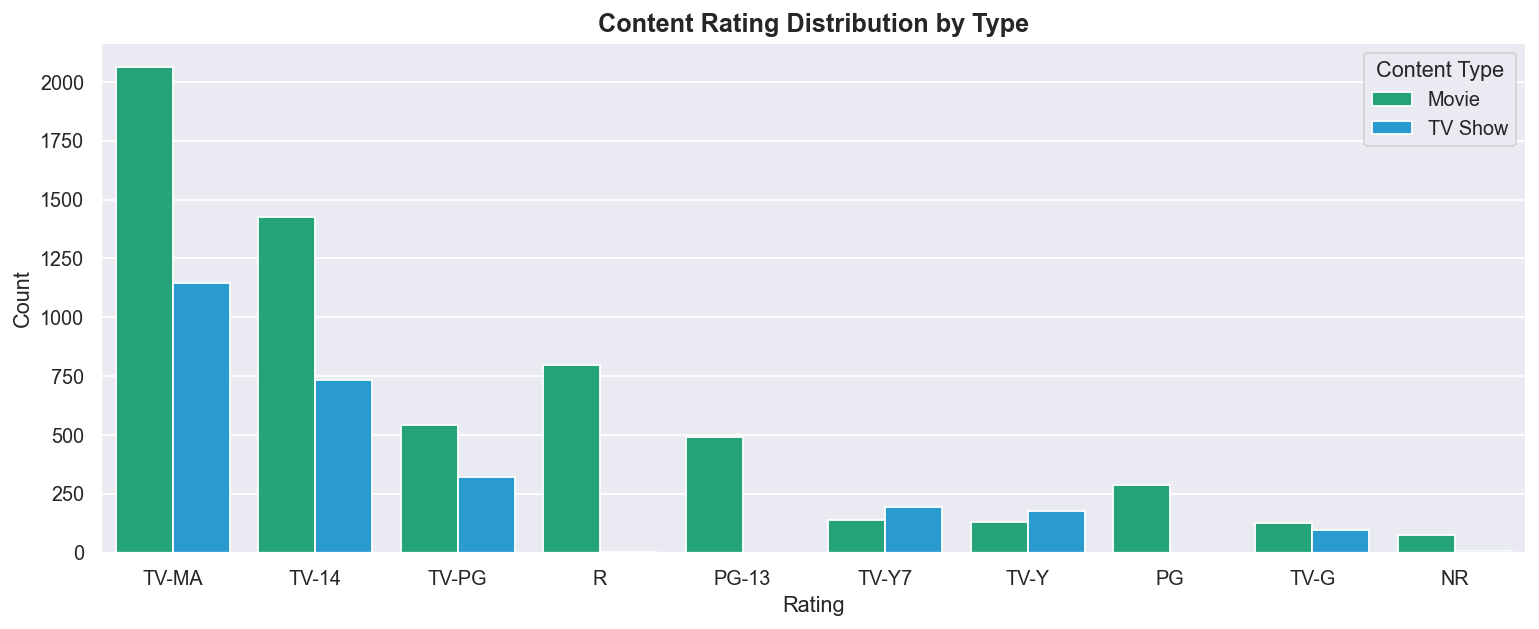

KEY FINDING: Most common rating = TV-MA ( 3211 titles)


In [11]:
rating_order = df['rating'].value_counts().head(10).index
 
fig, ax = plt.subplots(figsize=(12, 5))
sns.countplot(data=df, x='rating', order=rating_order,
              hue='type', palette={'Movie':'#10B981','TV Show':'#0EA5E9'},
              ax=ax)
ax.set_title('Content Rating Distribution by Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')  ;  ax.set_ylabel('Count')
ax.legend(title='Content Type')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Exploratory Data Analysis/Net_flix_EDA/visuals/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
 
top_rating = df['rating'].value_counts().idxmax()
top_count  = df['rating'].value_counts().max()
print('KEY FINDING: Most common rating =', top_rating, '(', top_count, 'titles)')

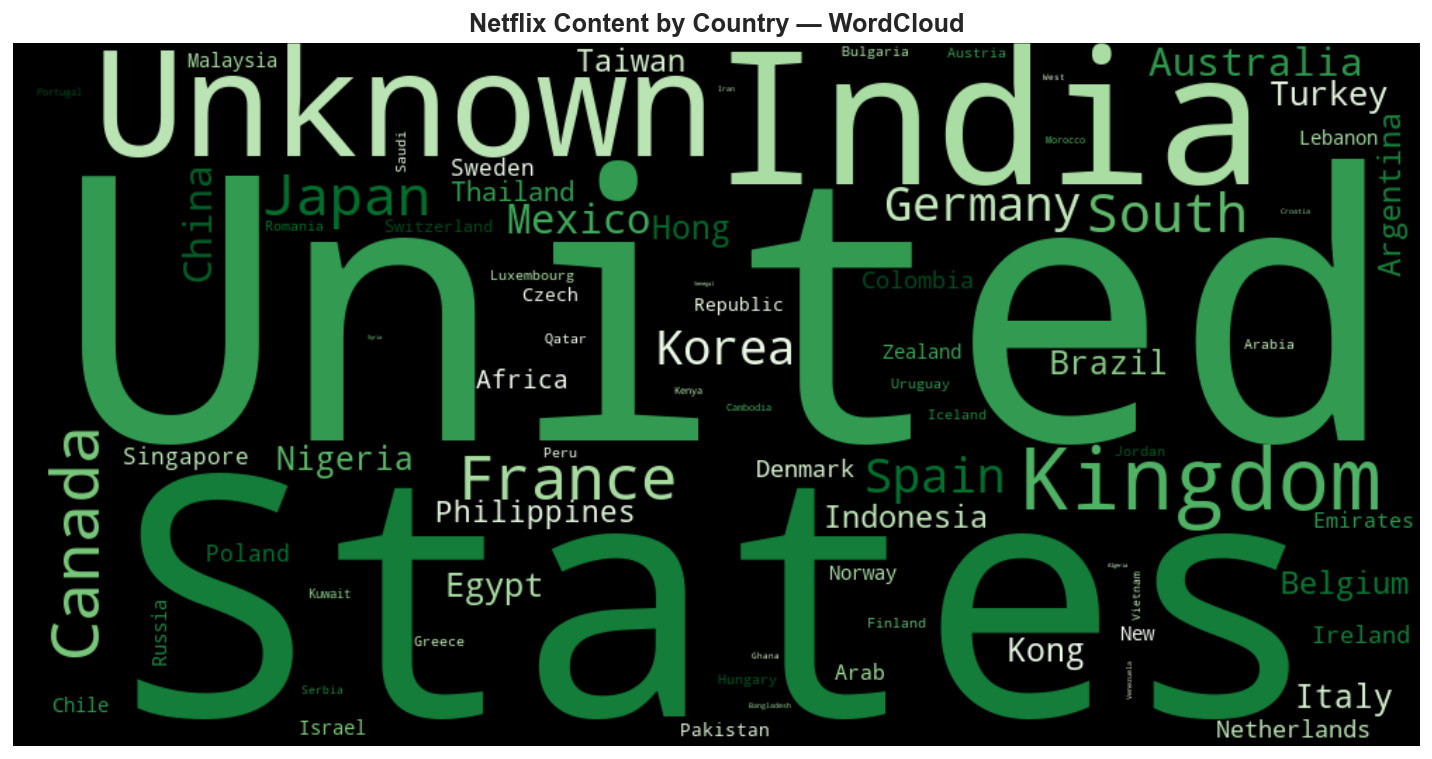

WordCloud saved


In [12]:
country_text = ' '.join(
    df['country'].dropna()
    .str.replace(', ', ' ').str.replace(',', ' '))
 
wc = WordCloud(
    background_color='black',
    width=1000, height=500,
    max_words=80,
    colormap='Greens',
    collocations=False
).generate(country_text)
 
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Netflix Content by Country — WordCloud',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/Exploratory Data Analysis/Net_flix_EDA/visuals/country_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('WordCloud saved')

# Key Findings — Netflix EDA
 
## Summary 
| # | Finding                      |  Value |
|---|---------                     |------------|
| 1 | Movies vs TV Shows split     | 69.6 % is Movies,30.4 % is TV Shows |
| 2 | Number 1 genre               | International Movies : 2752 titles |
| 3 | Content growth 2015 to 2019  | 2359.0 % |
| 4 | Top producing country        | United States ( 3689 titles) |
| 5 | Most common rating           | TV-MA ( 3211 titles) |
 
## Key Observations
1. Netflix shifted heavily to original content after 2015
2. International content from India, UK, Japan growing fast
3. TV-MA dominates — platform targets adult audiences